In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
df = pd.read_csv("/content/ToyotaCorolla - MLR.csv")
df.rename(columns={'Age_08_04': 'Age', 'cc': 'CC'}, inplace=True)
#Load and Understand the Datase


In [ ]:
f = pd.read_csv("/content/ToyotaCorolla - MLR.csv")
df = df[['Price','Age','KM','HP','CC']]
X = df.drop('Price', axis=1)
y = df['Price']

# VIF calculation
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Feature,VIF
0,Age,12.557975
1,KM,6.341422
2,HP,16.972157
3,CC,13.332828


In [ ]:

print("\nFirst 5 rows of data:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nSummary Statistics:\n", df.describe())


First 5 rows of data:
    Price  Age     KM Fuel_Type  HP  Automatic    CC  Doors  Cylinders  Gears  \
0  13500   23  46986    Diesel  90          0  2000      3          4      5   
1  13750   23  72937    Diesel  90          0  2000      3          4      5   
2  13950   24  41711    Diesel  90          0  2000      3          4      5   
3  14950   26  48000    Diesel  90          0  2000      3          4      5   
4  13750   30  38500    Diesel  90          0  2000      3          4      5   

   Weight  
0    1165  
1    1165  
2    1165  
3    1165  
4    1170  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age        1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-nu

In [ ]:
print("\nMissing Values in Each Column:\n", df.isnull().sum())


Missing Values in Each Column:
 Price        0
Age          0
KM           0
Fuel_Type    0
HP           0
Automatic    0
CC           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


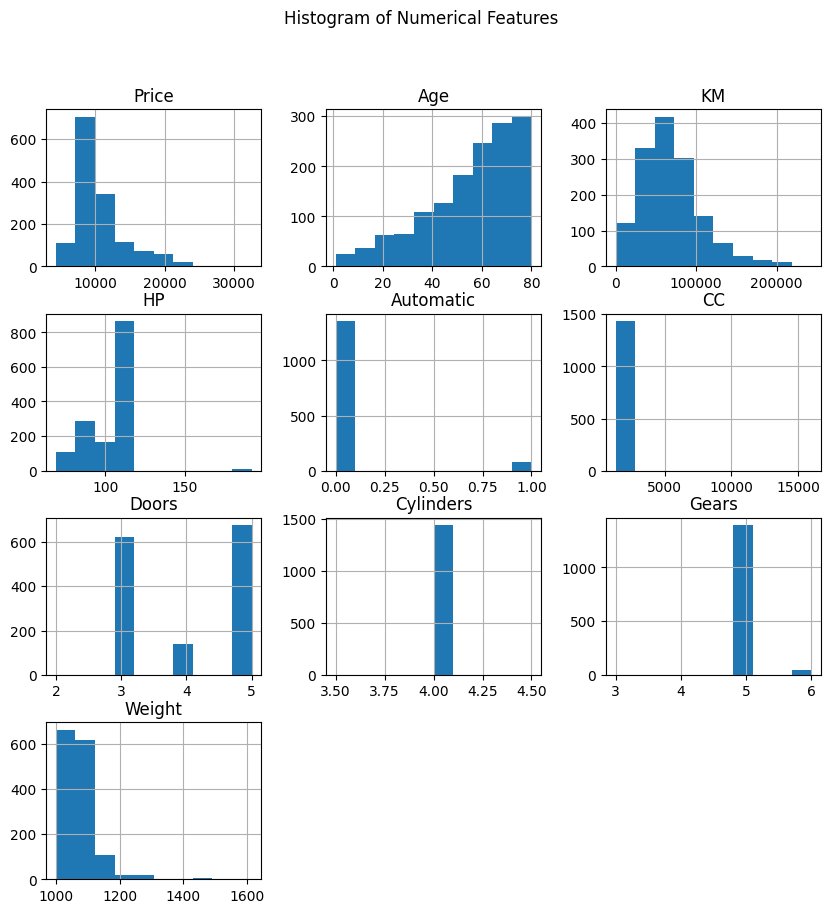

In [ ]:
df.hist(figsize=(10, 10))
plt.suptitle("Histogram of Numerical Features")
plt.show()
#Histograms are useful for visualizing the distribution of a single numerical variable.

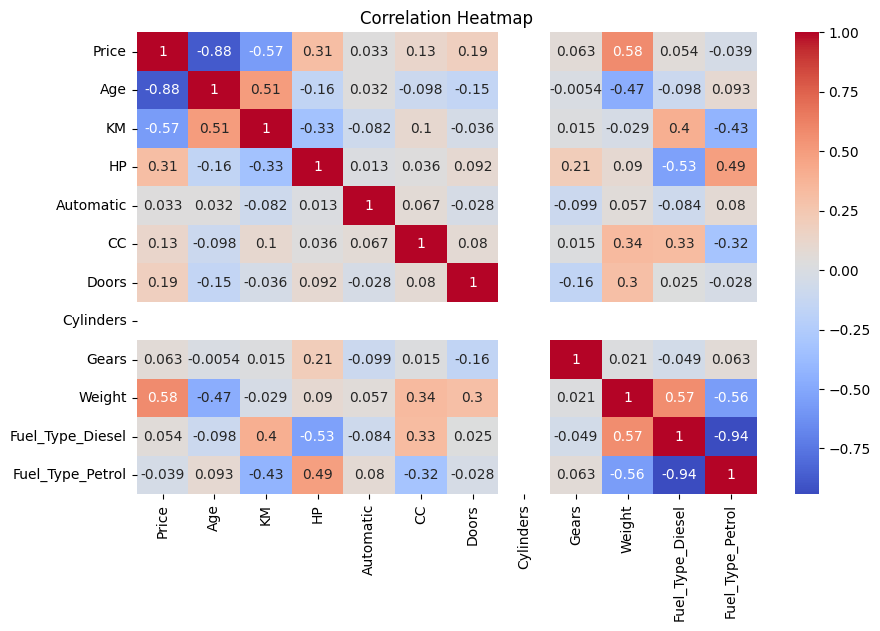

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
#The correlation heatmap helps visualize the relationships between your features and the target variable (Price), as well as the relationships between the features themselves.
#This can be useful for identifying features that are highly correlated with the target and identifying multicollinearity among features.

In [ ]:
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_scaled)

In [ ]:
def evaluate_model(true, pred):
    r2 = r2_score(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    return r2, rmse, mae

lr_r2, lr_rmse, lr_mae = evaluate_model(y_test, y_pred)
#This function is a convenient way to evaluate the performance of different regression models consistently using the same set of metrics.

In [ ]:
print("\nLinear Regression Performance:")
print("R² Score:", lr_r2)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)


Linear Regression Performance:
R² Score: 0.8348888040611081
RMSE: 1484.265415329652
MAE: 990.8872739193968


In [ ]:
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

In [ ]:
ridge_r2, ridge_rmse, ridge_mae = evaluate_model(y_test, ridge_pred)
print("\nRidge Regression Performance:")
print("Best Alpha:", ridge.alpha_)
print("R² Score:", ridge_r2)
print("RMSE:", ridge_rmse)
print("MAE:", ridge_mae)


Ridge Regression Performance:
Best Alpha: 100.0
R² Score: 0.841677506959896
RMSE: 1453.4316612220032
MAE: 993.7386431587651


In [ ]:
lasso = LassoCV(alphas=[0.01, 0.1, 1, 10], max_iter=10000)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
#This code cell trains a Lasso Regression model using cross-validation to find the best alpha value

In [ ]:

lasso_r2, lasso_rmse, lasso_mae = evaluate_model(y_test, lasso_pred)
print("\nLasso Regression Performance:")
print("Best Alpha:", lasso.alpha_)
print("R² Score:", lasso_r2)
print("RMSE:", lasso_rmse)
print("MAE:", lasso_mae)
#It represents the average absolute difference between the predicted and actual values. Like RMSE, a lower MAE indicates a better fit.


Lasso Regression Performance:
Best Alpha: 10.0
R² Score: 0.8371084268156417
RMSE: 1474.2550204823071
MAE: 992.2092042666142


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R² Score": [lr_r2, ridge_r2, lasso_r2],
    "RMSE": [lr_rmse, ridge_rmse, lasso_mae]
})

print("\nModel Comparison:\n", results)
#DataFrame, showing the performance metrics side-by-side for easy comparison.


Model Comparison:
                Model  R² Score         RMSE
0  Linear Regression  0.834889  1484.265415
1   Ridge Regression  0.841678  1453.431661
2   Lasso Regression  0.837108   992.209204


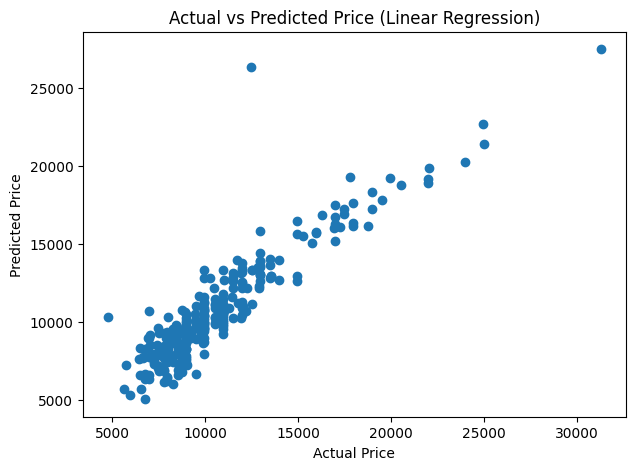

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Linear Regression)")
plt.show()
#This code cell visualizes the performance of the Linear Regression model by plotting the actual prices against the predicted prices

In [ ]:
# Model 1 - All features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr1 = LinearRegression().fit(X_train, y_train)
pred1 = lr1.predict(X_test)
r2_1 = r2_score(y_test, pred1)
mse_1 = mean_squared_error(y_test, pred1)
r2_1, mse_1

(0.81353916294059, 2487907.576503589)

In [ ]:
# Model 2 - Identify weakest feature
# Coefficient inspection
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr1.coef_})
coef_df
# Assume weakest = lowest absolute coefficient
weak_feature = coef_df.iloc[coef_df['Coefficient'].abs().argmin()]['Feature']
weak_feature


'KM'

In [ ]:
# Model 3: Remove weakest feature and rebuild
X2 = X.drop(columns=[weak_feature])
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
lr3 = LinearRegression().fit(X2_train, y2_train)
pred3 = lr3.predict(X2_test)
r2_3 = r2_score(y2_test, pred3)
mse_3 = mean_squared_error(y2_test, pred3)
r2_3, mse_3

(0.8012648062224936, 2651681.726385421)

In [ ]:
## Model Comparison Summary
summary = pd.DataFrame({
    'Model': ['Model 1 (All Features)', 'Model 3 (After Removing Weakest Feature)'],
    'R2 Score': [r2_1, r2_3],
    'MSE': [mse_1, mse_3]
})
summary

,Model,R2 Score,MSE
0,Model 1 (All Features),0.813539,2.487908e+06
1,Model 3 (After Removing Weakest Feature),0.801265,2.651682e+06


In summary, for this dataset, removing the 'KM' feature resulted in a marginally less accurate model but simplified it, which could be beneficial for interpretability.

Interview Question Answers
1. What is Normalization & Standardization?

Normalization scales values between 0 and 1.

Standardization transforms data to have mean 0 and standard deviation 1.

Prevents features with large values (e.g., weight, km) from dominating the regression model.

2. How to solve Multicollinearity in MLR?

Remove highly correlated variables.

Use Variance Inflation Factor (VIF).

Apply Ridge or Lasso Regression (penalty reduces overfitting).